# Extract transaction data with PaddleOCR

This notebook runs local OCR on cropped transaction images using PaddleOCR's PP-OCRv5 server detection and recognition models. A dataset selector lets you switch between a small test set and the complete crop set. The first model run downloads the pretrained files; subsequent inference can run offline from the local model cache.

## Import dependencies and locate the repository

Run this notebook with the `transactionsViz` kernel after installing `paddlepaddle` and `paddleocr`.

In [14]:
from pathlib import Path

import paddle
import paddleocr
from IPython.display import display
from paddleocr import PaddleOCR
from PIL import Image

print(f"PaddlePaddle version: {paddle.__version__}")
print(f"PaddleOCR version: {paddleocr.__version__}")

repo_root = Path.cwd()
if repo_root.name == "notebooks":
    repo_root = repo_root.parent

PaddlePaddle version: 3.3.1
PaddleOCR version: 3.7.0


## Select the dataset

Change only `dataset_name` to switch between the small test crop set and the complete crop set. The selected dataset controls the preview image, batch input folder, and output folder. `actual` is the default for the full run.

Dataset: actual
Images found: 335
Preview image: C:\Users\Johnson\MDS\TransactionsVisualizer\images\crops\Taiwan_2026_Jul_to_Sep_transactions\2026_07_08_a_band_001_y400-508.jpg
Output directory: C:\Users\Johnson\MDS\TransactionsVisualizer\outputs\ocr\Taiwan_2026_Jul_to_Sep_transactions
Size: 540 x 108 pixels


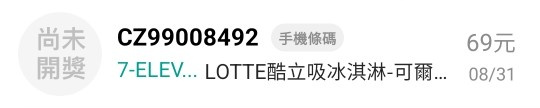

In [31]:
datasets = {
    "test": {
        "crop_folder": "test",
        "output_folder": "test",
    },
    "actual": {
        "crop_folder": "Taiwan_2026_Jul_to_Sep_transactions",
        "output_folder": "Taiwan_2026_Jul_to_Sep_transactions",
    },
}

dataset_name = "actual"  # Change to "test" for the smaller test run.
if dataset_name not in datasets:
    raise ValueError(f"dataset_name must be one of: {', '.join(datasets)}")

dataset = datasets[dataset_name]
input_dir = repo_root / "images" / "crops" / dataset["crop_folder"]
output_dir = repo_root / "outputs" / "ocr" / dataset["output_folder"]
image_paths = sorted(input_dir.glob("*.jpg"))

if not image_paths:
    raise FileNotFoundError(f"No JPG crops found in {input_dir}")

image_path = image_paths[0]

with Image.open(image_path) as source:
    crop = source.copy()

print(f"Dataset: {dataset_name}")
print(f"Images found: {len(image_paths)}")
print(f"Preview image: {image_path}")
print(f"Output directory: {output_dir}")
print(f"Size: {crop.width} x {crop.height} pixels")
display(crop)

## Initialize the local OCR pipeline

The screenshot is already upright and undistorted, so the orientation and unwarping modules are disabled. Model initialization may take longer the first time while the weights are downloaded.

In [32]:
ocr = PaddleOCR(
    text_detection_model_name="PP-OCRv5_server_det",
    text_recognition_model_name="PP-OCRv5_server_rec",
    use_doc_orientation_classify=False,
    use_doc_unwarping=False,
    use_textline_orientation=False,
    device="cpu",
    # Avoid PaddlePaddle 3.3.1's oneDNN/PIR attribute conversion error.
    enable_mkldnn=False,
)

Creating model: ('PP-OCRv5_server_det', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\Johnson\.paddlex\official_models\PP-OCRv5_server_det`.
Creating model: ('PP-OCRv5_server_rec', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\Johnson\.paddlex\official_models\PP-OCRv5_server_rec`.


## Run OCR on the selected dataset's preview image

In [33]:
results = ocr.predict(str(image_path))

for result in results:
    result.print()

{'res': {'input_path': 'C:\\Users\\Johnson\\MDS\\TransactionsVisualizer\\images\\crops\\Taiwan_2026_Jul_to_Sep_transactions\\2026_07_08_a_band_001_y400-508.jpg', 'page_index': None, 'model_settings': {'use_doc_preprocessor': False, 'use_textline_orientation': False}, 'dt_polys': array([[[ 35,  24],
        ...,
        [ 35,  54]],

       ...,

       [[114,  57],
        ...,
        [114,  81]]], shape=(6, 4, 2), dtype=int16), 'text_det_params': {'limit_side_len': 64, 'limit_type': 'min', 'thresh': 0.3, 'max_side_limit': 4000, 'box_thresh': 0.6, 'unclip_ratio': 1.5}, 'text_type': 'general', 'textline_orientation_angles': array([-1, ..., -1], shape=(6,)), 'text_rec_score_thresh': 0.0, 'return_word_box': False, 'rec_texts': ['尚未', 'CZ99008492', '手機條碼', '69元', '開獎', '7-ELEV...LOTTE酷立吸冰淇淋-可爾..08/31'], 'rec_scores': array([0.99731213, ..., 0.90364689], shape=(6,)), 'rec_polys': array([[[ 35,  24],
        ...,
        [ 35,  54]],

       ...,

       [[114,  57],
        ...,
        [1

## Split store name (teal) from description (black)

PaddleOCR often recognizes the lower row as one text box. Instead of splitting that text on spaces, the following code detects the horizontal extent of teal pixels and uses it to create separate store-name and description regions. Each region is OCRed independently during the main collection loop below, so no second folder pass is needed.

The coordinate limits are intentionally tailored to these 540-pixel-wide transaction crops: the useful lower row begins near `x=100`, while the date begins to the right of `x=455`.

In [34]:
import numpy as np


def find_store_and_description_boxes(image):
    """Return crop boxes for the teal store name and black description."""
    rgb = np.asarray(image.convert("RGB"))
    height, width = rgb.shape[:2]

    # Restrict color detection to the lower transaction-text row.
    row_top = min(45, height)
    row_bottom = height
    content_left = min(100, width)
    content_right = min(455, width)  # Exclude the date on the right.
    region = rgb[row_top:row_bottom, content_left:content_right]

    if region.size == 0:
        return None, None

    red = region[:, :, 0].astype(int)
    green = region[:, :, 1].astype(int)
    blue = region[:, :, 2].astype(int)

    # Teal letters have much stronger green/blue channels than red.
    teal_mask = (green > 90) & (blue > 80) & ((green - red) > 25) & ((blue - red) > 15)
    _, teal_x = np.where(teal_mask)

    if teal_x.size == 0:
        return None, None

    teal_left = content_left + int(teal_x.min())
    teal_right = content_left + int(teal_x.max()) + 1

    # Small margins retain antialiased letter edges without including much
    # text from the neighboring region.
    store_box = (max(content_left, teal_left - 4), row_top, min(content_right, teal_right + 4), row_bottom)
    description_left = min(content_right, teal_right + 5)
    description_box = (description_left, row_top, content_right, row_bottom)
    return store_box, description_box


def ocr_box(image, box, scale=3):
    """OCR one image region and return its combined text and mean confidence."""
    if box is None or box[2] - box[0] < 5 or box[3] - box[1] < 5:
        return "", None

    region = image.crop(box)
    enlarged = region.resize(
        (region.width * scale, region.height * scale),
        Image.Resampling.LANCZOS,
    )
    region_results = ocr.predict(np.asarray(enlarged))

    texts = []
    scores = []
    for result in region_results:
        payload = result.json
        data = payload.get("res", payload)
        for text, score in zip(data.get("rec_texts", []), data.get("rec_scores", [])):
            if text.strip():
                texts.append(text)
                scores.append(float(score))

    mean_score = sum(scores) / len(scores) if scores else None
    return " ".join(texts), mean_score

### Preview the detected split on one image

Inspect this preview before processing the full folder. The first image should show only the teal store name in the left preview and only the black purchased-item description in the right preview. If a future screenshot uses different colors or spacing, adjust the thresholds and coordinate limits above.

Store box: (113, 45, 194, 108)
Description box: (195, 45, 455, 108)


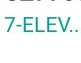

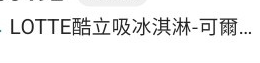

Store: '7-ELEV..' (confidence=0.9700103402137756)
Description: 'LOTTE酷立吸冰淇淋-可爾..' (confidence=0.936042308807373)


In [35]:
with Image.open(image_paths[0]) as source:
    sample_image = source.convert("RGB")

sample_store_box, sample_description_box = find_store_and_description_boxes(sample_image)
print(f"Store box: {sample_store_box}")
print(f"Description box: {sample_description_box}")
if sample_store_box is not None:
    display(sample_image.crop(sample_store_box))
if sample_description_box is not None:
    display(sample_image.crop(sample_description_box))

sample_store_text, sample_store_confidence = ocr_box(sample_image, sample_store_box)
sample_description_text, sample_description_confidence = ocr_box(
    sample_image, sample_description_box
)
print(f"Store: {sample_store_text!r} (confidence={sample_store_confidence})")
print(f"Description: {sample_description_text!r} (confidence={sample_description_confidence})")

## Run OCR on every image in the selected dataset

Generated artifacts are kept outside the source-image tree under the selected dataset's run folder in `outputs/ocr/`. The run folder contains raw PaddleOCR JSON, annotated preview images, a detection-level CSV, and an image-level summary CSV. Test and actual outputs use separate folders, so switching datasets does not overwrite the other run.

In [36]:
import pandas as pd

raw_json_dir = output_dir / "raw_json"
annotated_dir = output_dir / "annotated_images"
raw_json_dir.mkdir(parents=True, exist_ok=True)
annotated_dir.mkdir(parents=True, exist_ok=True)

print(f"Selected dataset: {dataset_name}")
print(f"Found {len(image_paths)} images in {input_dir}")
print(f"Output directory: {output_dir}")

Selected dataset: actual
Found 335 images in C:\Users\Johnson\MDS\TransactionsVisualizer\images\crops\Taiwan_2026_Jul_to_Sep_transactions
Output directory: C:\Users\Johnson\MDS\TransactionsVisualizer\outputs\ocr\Taiwan_2026_Jul_to_Sep_transactions


### Collect text, confidence scores, coordinates, and split fields

Each image is processed in one folder pass: full-image OCR collects text and coordinates, then separate OCR calls on the teal store-name and black description regions extract those fields. The detection-level table retains one row per full-image text box. The summary table includes the split fields and their confidence scores from the start.

In [37]:
detection_rows = []
summary_rows = []

for current_number, current_path in enumerate(image_paths, start=1):
    image_results = ocr.predict(str(current_path))
    with Image.open(current_path) as source:
        current_image = source.convert("RGB")

    store_box, description_box = find_store_and_description_boxes(current_image)
    store_name, store_confidence = ocr_box(current_image, store_box)
    description, description_confidence = ocr_box(current_image, description_box)

    for result in image_results:
        # Preserve PaddleOCR's complete output and a visual bounding-box preview.
        result.save_to_json(str(raw_json_dir))
        result.save_to_img(str(annotated_dir))

        payload = result.json
        data = payload.get("res", payload)
        texts = data.get("rec_texts", [])
        scores = data.get("rec_scores", [])
        boxes = data.get("rec_boxes", [])

        for detection_index, (text, score, box) in enumerate(
            zip(texts, scores, boxes), start=1
        ):
            x_min, y_min, x_max, y_max = (int(value) for value in box)
            detection_rows.append(
                {
                    "source_image": current_path.name,
                    "detection_index": detection_index,
                    "text": text,
                    "confidence": float(score),
                    "x_min": x_min,
                    "y_min": y_min,
                    "x_max": x_max,
                    "y_max": y_max,
                }
            )

        numeric_scores = [float(score) for score in scores]
        summary_rows.append(
            {
                "source_image": current_path.name,
                "store_name": store_name,
                "description": description,
                "store_confidence": store_confidence,
                "description_confidence": description_confidence,
                "detected_text_count": len(texts),
                "combined_text": " | ".join(texts),
                "mean_confidence": (
                    sum(numeric_scores) / len(numeric_scores) if numeric_scores else None
                ),
            }
        )

    print(f"[{current_number:02d}/{len(image_paths):02d}] {current_path.name}")

[01/335] 2026_07_08_a_band_001_y400-508.jpg
[02/335] 2026_07_08_a_band_002_y510-617.jpg
[03/335] 2026_07_08_a_band_003_y619-727.jpg
[04/335] 2026_07_08_a_band_004_y729-836.jpg
[05/335] 2026_07_08_a_band_005_y838-946.jpg
[06/335] 2026_07_08_a_band_006_y948-1055.jpg
[07/335] 2026_07_08_a_band_007_y1057-1165.jpg
[08/335] 2026_07_08_a_band_008_y1167-1274.jpg
[09/335] 2026_07_08_a_band_009_y1276-1384.jpg
[10/335] 2026_07_08_a_band_010_y1386-1493.jpg
[11/335] 2026_07_08_a_band_011_y1495-1603.jpg
[12/335] 2026_07_08_a_band_012_y1605-1712.jpg
[13/335] 2026_07_08_a_band_013_y1714-1822.jpg
[14/335] 2026_07_08_a_band_014_y1824-1931.jpg
[15/335] 2026_07_08_a_band_015_y1933-2041.jpg
[16/335] 2026_07_08_a_band_016_y2043-2150.jpg
[17/335] 2026_07_08_a_band_017_y2152-2260.jpg
[18/335] 2026_07_08_a_band_018_y2262-2369.jpg
[19/335] 2026_07_08_a_band_019_y2371-2479.jpg
[20/335] 2026_07_08_a_band_020_y2481-2588.jpg
[21/335] 2026_07_08_a_band_021_y2590-2698.jpg
[22/335] 2026_07_08_a_band_022_y2700-2807.jpg

### Export the CSV files

`utf-8-sig` preserves Traditional Chinese text and also makes the files easier to open directly in Microsoft Excel.

In [38]:
detections_df = pd.DataFrame(detection_rows)
summary_df = pd.DataFrame(summary_rows)

detections_csv = output_dir / "ocr_detections.csv"
summary_csv = output_dir / "ocr_image_summary.csv"
detections_df.to_csv(detections_csv, index=False, encoding="utf-8-sig")
summary_df.to_csv(summary_csv, index=False, encoding="utf-8-sig")

print(f"Saved {len(detections_df)} detections to {detections_csv}")
print(f"Saved {len(summary_df)} image summaries to {summary_csv}")
display(summary_df)
display(detections_df.head(20))

Saved 2346 detections to C:\Users\Johnson\MDS\TransactionsVisualizer\outputs\ocr\Taiwan_2026_Jul_to_Sep_transactions\ocr_detections.csv
Saved 335 image summaries to C:\Users\Johnson\MDS\TransactionsVisualizer\outputs\ocr\Taiwan_2026_Jul_to_Sep_transactions\ocr_image_summary.csv


,source_image,store_name,description,store_confidence,description_confidence,detected_text_count,combined_text,mean_confidence
0,2026_07_08_a_band_001_y400-508.jpg,7-ELEV..,LOTTE酷立吸冰淇淋-可爾..,0.970010,0.936042,6,尚未 | CZ99008492 | 手機條碼 | 69元 | 開獎 | 7-ELEV...L...,0.943688
1,2026_07_08_a_band_002_y510-617.jpg,王記府城肉粽...肉粽,,0.876735,NaN,7,尚未 | DF00174568 | 紙本電子 | 145元 | 開獎 | 王記府城肉粽.肉粽...,0.941119
2,2026_07_08_a_band_003_y619-727.jpg,全家,福樂超能蛋白營養牛乳可可口味,0.999370,0.994812,7,尚未 | CL77674350 | 手機條碼 | 39元 | 開獎 | 全家 福樂超能蛋白營...,0.977044
3,2026_07_08_a_band_004_y729-836.jpg,和興國際企業...,尊爵享受60,0.902775,0.999806,7,尚未 | DR33810875 | 手機條碼 | 509元 | 開獎 | 和興国際企業......,0.951487
4,2026_07_08_a_band_005_y838-946.jpg,山颯有限公司...,餐飲,0.817535,0.980824,7,尚未 | DE93338867 | 手機條碼 | 660元 | 開獎 | 山颯有限公司.餐飲...,0.965166
...,...,...,...,...,...,...,...,...
330,2026_09_10_band_039_y4561-4669.jpg,全家,勁量鹼性高科技4號2入,0.999743,0.903184,7,尚未 | EM50868472 | 手機條碼 | 109元 | 開獎 | 全家勁量鹼性高科技...,0.959847
331,2026_09_10_band_040_y4671-4778.jpg,泰初安安商行...,巧克力厚片,0.937067,0.998451,7,尚未 | FV23946043 | 手機條碼 | 145元 | 開獎 | 泰初安安商行......,0.974169
332,2026_09_10_band_041_y4780-4888.jpg,全家,成人醫用口罩一藍,0.999681,0.979348,7,尚未 | EM50868464 | 手機條碼 | 45元 | 開獎 | 全家 成人醫用口罩一...,0.968803
333,2026_09_10_band_042_y4890-4997.jpg,金雨企業,FIN補給飲料 (PET),0.996618,0.955509,7,尚未 | EP02089652 | 手機條碼 | 29元 | 開獎 | 金雨企業FIN補給飲...,0.976996


,source_image,detection_index,text,confidence,x_min,y_min,x_max,y_max
0,2026_07_08_a_band_001_y400-508.jpg,1,尚未,0.997312,35,24,87,54
1,2026_07_08_a_band_001_y400-508.jpg,2,CZ99008492,0.999036,116,25,259,47
2,2026_07_08_a_band_001_y400-508.jpg,3,手機條碼,0.958184,276,27,338,47
3,2026_07_08_a_band_001_y400-508.jpg,4,69元,0.999337,463,28,518,56
4,2026_07_08_a_band_001_y400-508.jpg,5,開獎,0.804614,34,53,87,83
5,2026_07_08_a_band_001_y400-508.jpg,6,7-ELEV...LOTTE酷立吸冰淇淋-可爾..08/31,0.903647,114,57,516,84
6,2026_07_08_a_band_002_y510-617.jpg,1,尚未,0.996083,35,23,87,54
7,2026_07_08_a_band_002_y510-617.jpg,2,DF00174568,0.999155,116,25,258,47
8,2026_07_08_a_band_002_y510-617.jpg,3,紙本電子,0.871108,274,28,336,47
9,2026_07_08_a_band_002_y510-617.jpg,4,145元,0.999660,452,30,516,54


## Extract receipt code, amount, and purchase date

A typical `combined_text` value has seven segments separated by six pipes:

```text
status | receipt code | barcode type | amount | prize status | store/description | date
```

The number of intermediate OCR segments can vary. The stable positions are the second segment for the receipt code, the fourth for the amount, and the final segment for the date. The parser strips all non-digits from the amount, stores it as a nullable integer, and converts `MM/DD` into a pandas datetime using 2026 as the year. A row too short to contain these positions receives missing values and `parse_valid=False`.

In [39]:
import re


def parse_combined_text(combined_text, year=2026):
    parts = [part.strip() for part in str(combined_text).split("|")]
    if len(parts) < 5:
        return {
            "receipt_code": None,
            "amount": None,
            "date": pd.NaT,
            "parse_valid": False,
        }

    receipt_code = parts[1]
    amount_digits = re.sub(r"[^0-9]", "", parts[3])
    purchase_date = pd.to_datetime(
        f"{year}/{parts[-1]}",
        format="%Y/%m/%d",
        errors="coerce",
    )

    parse_valid = bool(receipt_code and amount_digits and not pd.isna(purchase_date))
    return {
        "receipt_code": receipt_code or None,
        "amount": int(amount_digits) if amount_digits else None,
        "date": purchase_date,
        "parse_valid": parse_valid,
    }


parsed_df = summary_df["combined_text"].apply(parse_combined_text).apply(pd.Series)
summary_df = summary_df.drop(
    columns=["receipt_code", "amount", "date", "parse_valid"],
    errors="ignore",
).join(parsed_df)
summary_df["amount"] = summary_df["amount"].astype("Int64")
summary_df["date"] = pd.to_datetime(summary_df["date"])

# ISO-formatted dates are unambiguous when the CSV is opened elsewhere.
summary_df.to_csv(
    summary_csv,
    index=False,
    encoding="utf-8-sig",
    date_format="%Y-%m-%d",
)

invalid_count = int((~summary_df["parse_valid"]).sum())
print(f"Updated {summary_csv}")
print(f"Rows requiring review: {invalid_count}")
display(
    summary_df[
        ["source_image", "receipt_code", "store_name", "description", "amount", "date", "parse_valid"]
    ]
)

Updated C:\Users\Johnson\MDS\TransactionsVisualizer\outputs\ocr\Taiwan_2026_Jul_to_Sep_transactions\ocr_image_summary.csv
Rows requiring review: 7


,source_image,receipt_code,store_name,description,amount,date,parse_valid
0,2026_07_08_a_band_001_y400-508.jpg,CZ99008492,7-ELEV..,LOTTE酷立吸冰淇淋-可爾..,69,NaT,False
1,2026_07_08_a_band_002_y510-617.jpg,DF00174568,王記府城肉粽...肉粽,,145,2026-08-31,True
2,2026_07_08_a_band_003_y619-727.jpg,CL77674350,全家,福樂超能蛋白營養牛乳可可口味,39,2026-08-31,True
3,2026_07_08_a_band_004_y729-836.jpg,DR33810875,和興國際企業...,尊爵享受60,509,2026-08-30,True
4,2026_07_08_a_band_005_y838-946.jpg,DE93338867,山颯有限公司...,餐飲,660,2026-08-30,True
...,...,...,...,...,...,...,...
330,2026_09_10_band_039_y4561-4669.jpg,EM50868472,全家,勁量鹼性高科技4號2入,109,2026-08-31,True
331,2026_09_10_band_040_y4671-4778.jpg,FV23946043,泰初安安商行...,巧克力厚片,145,2026-08-31,True
332,2026_09_10_band_041_y4780-4888.jpg,EM50868464,全家,成人醫用口罩一藍,45,2026-08-31,True
333,2026_09_10_band_042_y4890-4997.jpg,EP02089652,金雨企業,FIN補給飲料 (PET),29,2026-08-31,True
